## Predicting Sleep Disorders

Sleep disorders are a global health crisis, affecting hundreds of millions of people worldwide. An estimated 850 million adults suffer from insomnia globally, while nearly 1 billion people are affected by obstructive sleep apnea. In total, up to one-third of the adult population experiences sleep disturbances.

## IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


## DATA EXPLORATION

In [2]:
# Load the dataset  
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df.shape

(374, 13)

In [4]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [6]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## DATA MODIFICATION AND CLEANING

By observation we can see that people doesnot effect with "Slip Disorder" are mention as Nan.. but by the case study we got that they are "Healthy".. so we need to modify this...

In [7]:
# Nan here means that the person is healthy and does not have any sleep disorder. So we will fill the NaN values in the 'Sleep Disorder' column with 'Healthy'.
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('Healthy')

# Verify the change
df.head(5)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Healthy
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Healthy
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Healthy
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


CREATING AGE GROUP

In [8]:
# Define bins and labels
bins = [20, 30, 40, 50, 60]   # boundaries
labels = [1, 2, 3, 4]       # group IDs

# Create a new column "Age Group"
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Verify the result
print(df[['Age', 'Age Group']].head(5))


   Age Age Group
0   27         1
1   28         1
2   28         1
3   28         1
4   28         1


In [9]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Age Group
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Healthy,1
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Healthy,1
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Healthy,1
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1


In [10]:
# THE UNIQUE VALUES IN THE OCCUPATION COLUMN
df['Occupation'].unique()


array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
       'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
       'Salesperson', 'Manager'], dtype=object)

GROUP BY OCCUPATION

In [11]:
# Define a mapping dictionary
occupation_map = {
    'Doctor': 'Health Professional',
    'Nurse': 'Health Professional',
    'Software Engineer': 'Technology',
    'Engineer': 'Technology',
    'Scientist': 'Research',
    'Teacher': 'Education',
    'Accountant': 'Finance',
    'Lawyer': 'Legal',
    'Sales Representative': 'Sales',
    'Salesperson': 'Sales',
    'Manager': 'Management'
}

# Apply the mapping to create a new column
df['Occupation Category'] = df['Occupation'].map(occupation_map)

# Verify the result
print(df[['Occupation', 'Occupation Category']].head(10))


             Occupation  Occupation Category
0     Software Engineer           Technology
1                Doctor  Health Professional
2                Doctor  Health Professional
3  Sales Representative                Sales
4  Sales Representative                Sales
5     Software Engineer           Technology
6               Teacher            Education
7                Doctor  Health Professional
8                Doctor  Health Professional
9                Doctor  Health Professional


SPLITING "Blood Pressure" into 'Systolic_BP' and 'Diastolic_BP'

In [12]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

df.drop('Blood Pressure', axis=1, inplace=True)

remove unwanted column

In [13]:
df.drop(columns=['Person ID'], inplace=True)

create a copy of actual df

In [14]:
df_n = df.copy(deep=True)

In [15]:
df_n.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Age Group,Occupation Category,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,1,Technology,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,1,Health Professional,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,1,Health Professional,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,1,Sales,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,1,Sales,140,90


# Exploratory Data Analysis (EDA)

DISTRIBUTION OF SLEEP DISORDER

In [16]:


# Example: assuming your column is named 'Sleep Disorder'
df['Sleep_Disorder_Grouped'] = df['Sleep Disorder'].replace({
    'Sleep Apnea': 'Sleep Disorder',
    'Insomnia': 'Sleep Disorder',
    'Healthy': 'Healthy'
})

# Check the new distribution
print(df['Sleep_Disorder_Grouped'].value_counts(normalize=True) * 100)


Sleep_Disorder_Grouped
Healthy           58.55615
Sleep Disorder    41.44385
Name: proportion, dtype: float64


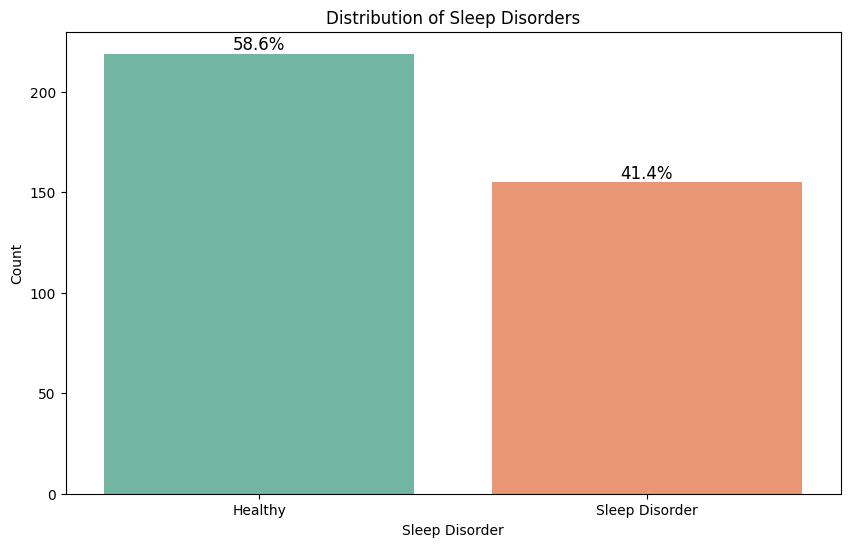

In [17]:
# CREATE A VISUALTION OF THE DISTRIBUTION OF SLEEP DISORDERS

# Count values
counts = df['Sleep_Disorder_Grouped'].value_counts()
total = len(df)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Sleep_Disorder_Grouped', data=df, palette='Set2')

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height/total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title('Distribution of Sleep Disorders')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.show()



Gender wise sleep disorder prediction

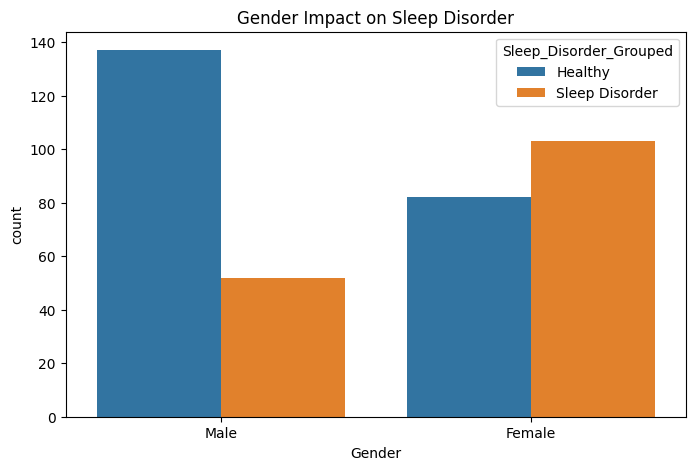

Gender
Male      50.534759
Female    49.465241
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='Sleep_Disorder_Grouped', data=df)

plt.title("Gender Impact on Sleep Disorder")
plt.show()
print(df['Gender'].value_counts(normalize=True) * 100)

Distribution of sleep Disorder By Age

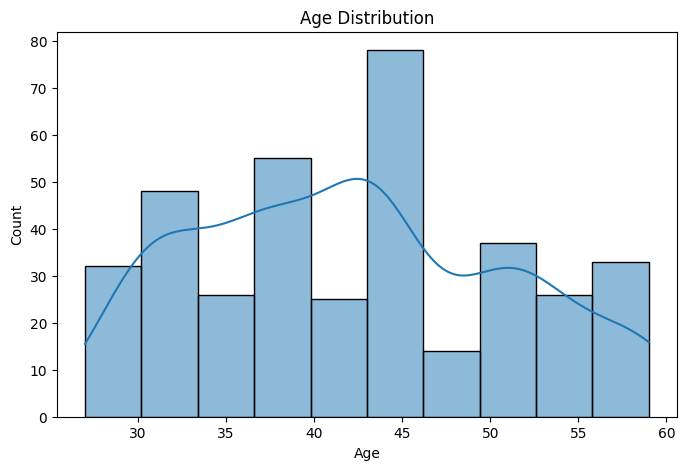

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)

plt.title("Age Distribution")
plt.show()

Investigate the relationship between lifestyle factors (e.g., physical activity, stress levels) and sleep disorders. 

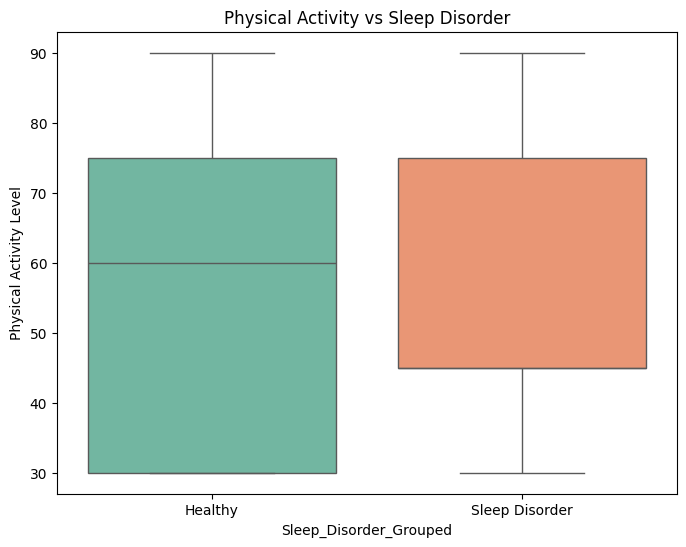

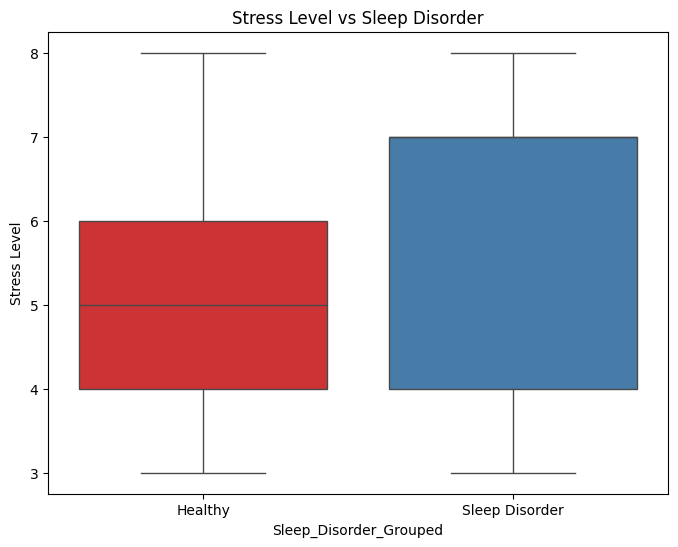

In [20]:
## Investigate the relationship between lifestyle factors and sleep disorders. 

# grouped Sleep Apnea + Insomnia into "Sleep Disorder"
df['Sleep_Disorder_Grouped'] = df['Sleep Disorder'].replace({
    'Sleep Apnea': 'Sleep Disorder',
    'Insomnia': 'Sleep Disorder',
    'Healthy': 'Healthy'
})

# Plot Physical Activity vs Sleep Disorder
plt.figure(figsize=(8,6))
sns.boxplot(x='Sleep_Disorder_Grouped', y='Physical Activity Level', data=df, palette='Set2')
plt.title('Physical Activity vs Sleep Disorder')
plt.show()

# Plot Stress Level vs Sleep Disorder
plt.figure(figsize=(8,6))
sns.boxplot(x='Sleep_Disorder_Grouped', y='Stress Level', data=df, palette='Set1')
plt.title('Stress Level vs Sleep Disorder')
plt.show()



physical activity wise sleep Disorder Distribution

Healthy group:

Median ~60, but lower quartile ~30 → wider spread, meaning activity levels vary a lot.

Includes both sedentary and highly active individuals.

Sleep Disorder group:

Median also ~60, but lower quartile ~45 → fewer very low-activity individuals.

Distribution is tighter, clustering around moderate-to-high activity.

Strees level factor in Sleep Disorder

Stress levels show a clear upward shift in the Sleep Disorder group.

Together, this suggests: stress is a stronger differentiator than physical activity when explaining sleep disorder prevalence.


----Assess the influence of BMI category and cardiovascular health indicators on sleep disorder risk.------

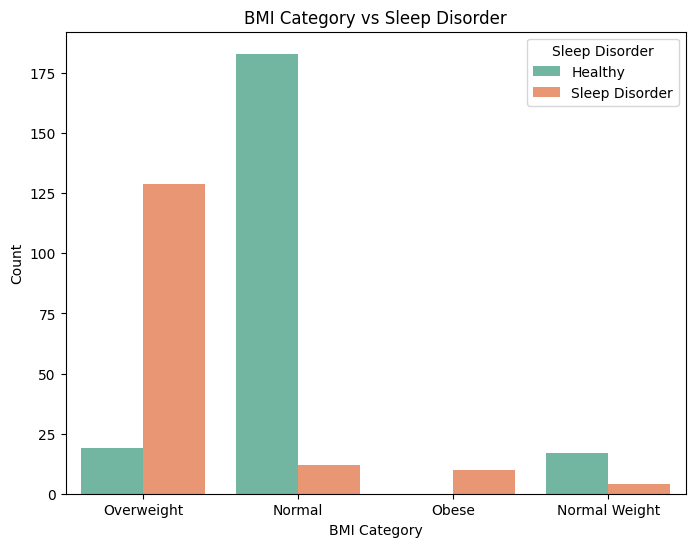

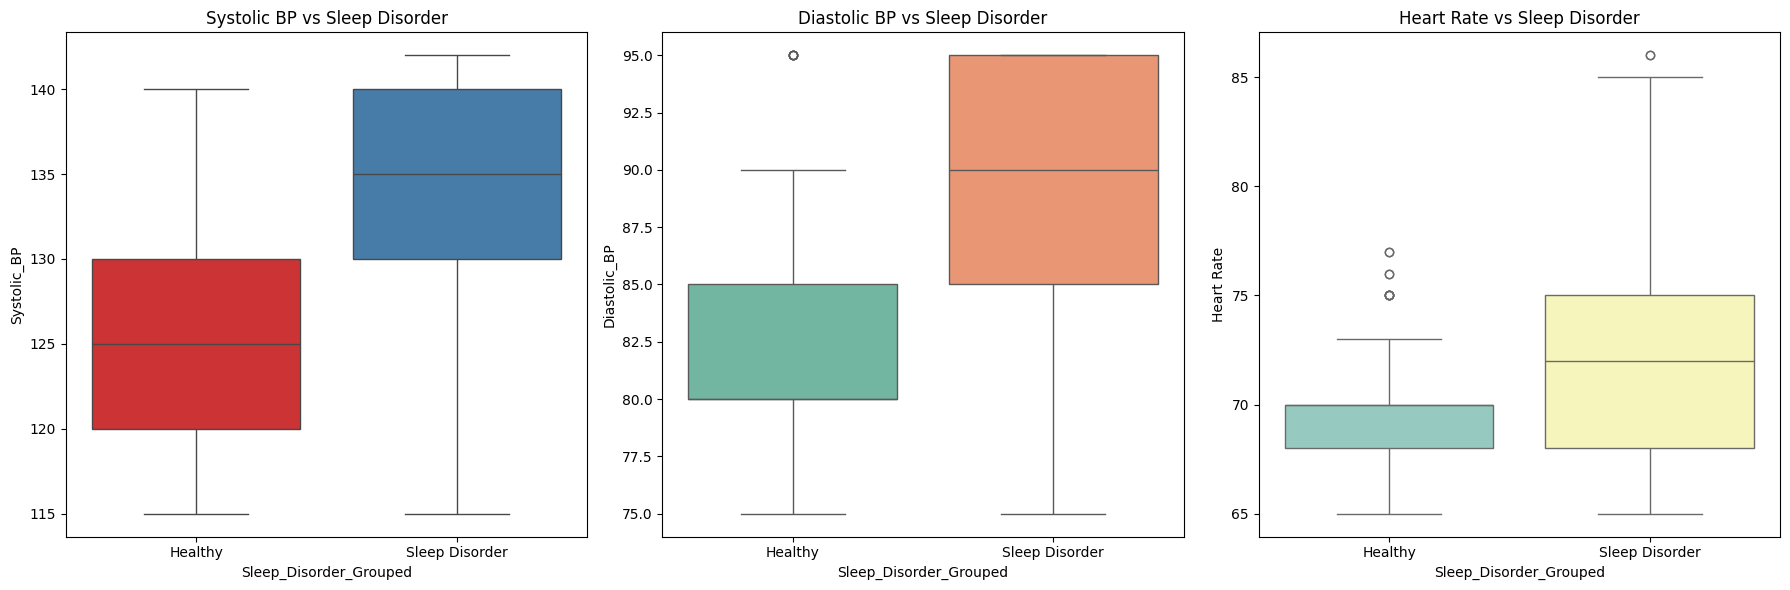

In [21]:
# df has columns: 'Sleep_Disorder_Grouped', 'BMI Category', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate'

# BMI Category vs Sleep Disorder (count plot)
plt.figure(figsize=(8,6))
sns.countplot(x='BMI Category', hue='Sleep_Disorder_Grouped', data=df, palette='Set2')
plt.title('BMI Category vs Sleep Disorder')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='Sleep Disorder')
plt.show()

# Cardiovascular Indicators vs Sleep Disorder (box plots side by side)
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.boxplot(x='Sleep_Disorder_Grouped', y='Systolic_BP', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Systolic BP vs Sleep Disorder')

sns.boxplot(x='Sleep_Disorder_Grouped', y='Diastolic_BP', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Diastolic BP vs Sleep Disorder')

sns.boxplot(x='Sleep_Disorder_Grouped', y='Heart Rate', data=df, palette='Set3', ax=axes[2])
axes[2].set_title('Heart Rate vs Sleep Disorder')

plt.tight_layout()
plt.show()


✨ Overall Narrative:

BMI and cardiovascular indicators (BP, heart rate) all show measurable differences between Healthy and Sleep Disorder groups.

Sleep disorders are consistently associated with higher cardiovascular strain, suggesting a bi-directional relationship: poor sleep worsens heart health, and poor heart health worsens sleep.

Stress and lifestyle factors amplify this risk, making sleep disorders a multifactorial condition.

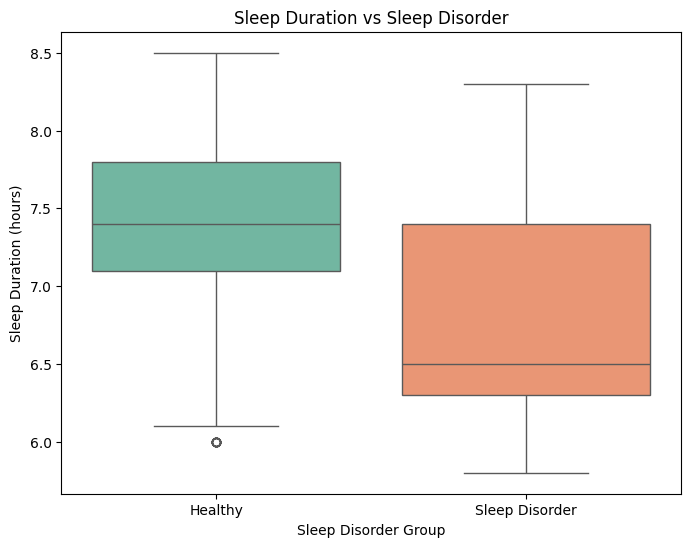

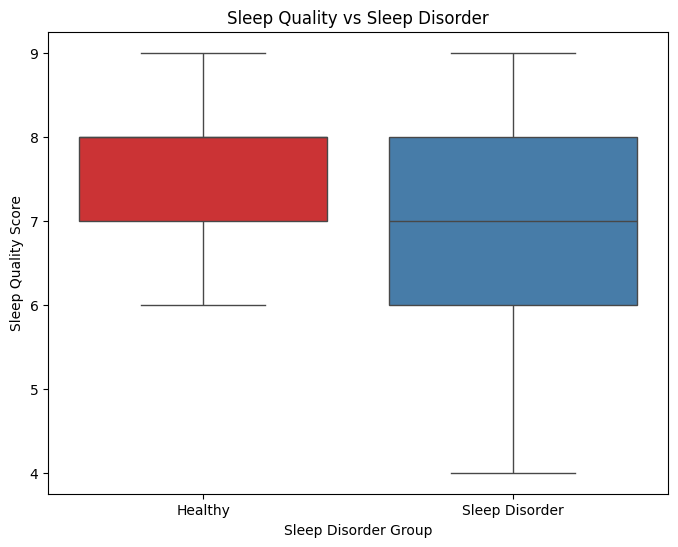

In [22]:
#df has columns: 'Sleep_Disorder_Grouped', 'Sleep Duration', 'Quality of Sleep'

# 1️⃣ Sleep Duration vs Sleep Disorder
plt.figure(figsize=(8,6))
sns.boxplot(x='Sleep_Disorder_Grouped', y='Sleep Duration', data=df, palette='Set2')
plt.title('Sleep Duration vs Sleep Disorder')
plt.xlabel('Sleep Disorder Group')
plt.ylabel('Sleep Duration (hours)')
plt.show()

 ##2️⃣ Sleep Quality vs Sleep Disorder
plt.figure(figsize=(8,6))
sns.boxplot(x='Sleep_Disorder_Grouped', y='Quality of Sleep', data=df, palette='Set1')
plt.title('Sleep Quality vs Sleep Disorder')
plt.xlabel('Sleep Disorder Group')
plt.ylabel('Sleep Quality Score')
plt.show()



# FEATURE ENGINEERING

# lable Encoding

In [24]:
# Separate target column
target = df_n['Sleep Disorder']

# Drop target temporarily
features = df_n.drop('Sleep Disorder', axis=1)

# Apply One Hot Encoding
features_encoded = pd.get_dummies(
    features,
    drop_first=True
)

# Encode target separately
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
target_encoded = le_target.fit_transform(target)

# Final X and y
X = features_encoded
y = target_encoded

# SPLITING DATA SET

In [25]:
from sklearn.model_selection import train_test_split

# ✅ Use the already encoded features and target from the previous cell
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model BUilding (LGR, RF , DT)

In [26]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

# random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        44
           1       0.36      0.27      0.31        15
           2       0.50      0.38      0.43        16

    accuracy                           0.60        75
   macro avg       0.51      0.48      0.49        75
weighted avg       0.57      0.60      0.58        75

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.92      0.80      0.86        15
           2       0.79      0.94      0.86        16

    accuracy                           0.93        75
   macro avg       0.90      0.90      0.90        75
weighted avg       0.94      0.93      0.93        75

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1

# Hyper parametre Tuning on best Performing Model

 Random Forest is the best performing model here.
It achieves the highest accuracy, strongest balance across classes, and superior F1-scores compared to Logistic Regression and Decision Tree.

In [27]:
# ✅ Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ✅ GridSearchCV setup
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    n_jobs=-1,           # use all cores
    scoring='accuracy',
    verbose=2
)

# ✅ Fit grid search
grid_search.fit(X_train, y_train)

# ✅ Best parameters
print("Best Parameters:", grid_search.best_params_)

# ✅ Evaluate best model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy: 0.92

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        44
           1       0.92      0.73      0.81        15
           2       0.75      0.94      0.83        16

    accuracy                           0.92        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.93      0.92      0.92        75



cross validation score

In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.68       0.69333333 1.         0.56       0.83783784]
Average CV Score: 0.7542342342342343


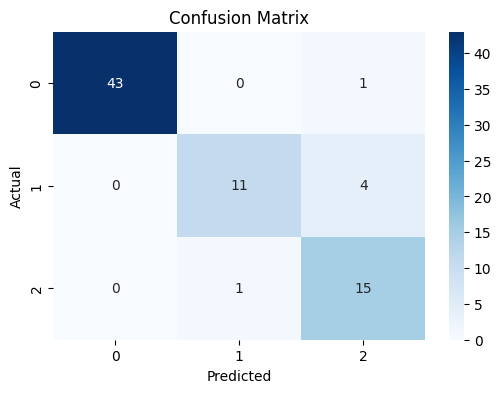

In [29]:
# Assuming y_test are true labels and y_pred are predictions from your model
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_rf.classes_,  # replace with your model.classes_ if different
            yticklabels=best_rf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Actual \ Predicted | 0   | 1   | 2
-------------------|-----|-----|----
0  HEALTHY         | 43  | 0   | 1
1  INSOMNIA        | 0   | 11  | 4
2  SLEEP APNEA     | 0   | 1   | 15

Class 0 (None/Healthy) →  43 TP, only 1 FN, no FP.

Class 1 (Insomnia) → 11 TP, but 4 FN → some insomnia cases missed.

Class 2 (Sleep Apnea) → 15 TP, only 1 FN, but 5 FP → strong recall, but a few false alarms.


R O C , A U C curve

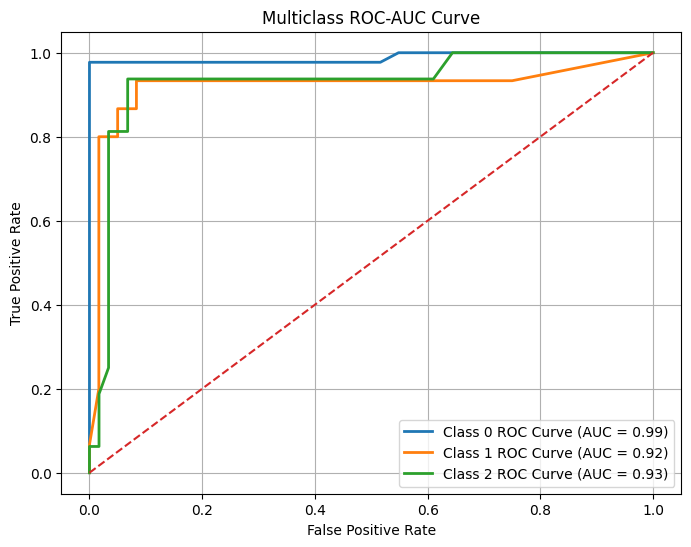

In [30]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert multiclass labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Predict probabilities
y_prob = best_rf.predict_proba(X_test)

# Number of classes
n_classes = y_test_bin.shape[1]

# Plot
plt.figure(figsize=(8,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'Class {i} ROC Curve (AUC = {roc_auc:.2f})'
    )

# Random prediction line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC-AUC Curve")

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

FEATURE IMPORTANCE

Model features: 33
X columns: 33


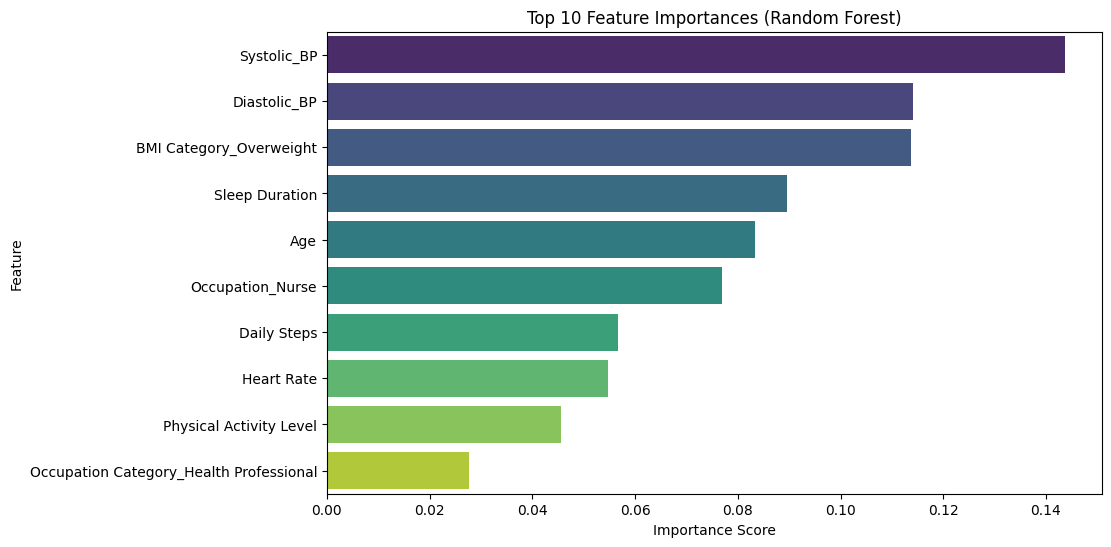

In [31]:
#  Ensure the number of features matches the model
print("Model features:", len(best_rf.feature_importances_))
print("X columns:", len(X.columns))

#  Use the model’s feature names directly (safer than X.columns)
feature_names = best_rf.feature_names_in_

#  Build DataFrame correctly
feature_importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_rf.feature_importances_
    })
    .sort_values(by='Importance', ascending=False)
    .reset_index(drop=True)
)

#  Display top 10
feature_importance_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


CREATING NEW TABLE OF IMPORTANCE FEATURE 

In [33]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                                    Feature  Importance
7                               Systolic_BP    0.143711
8                              Diastolic_BP    0.114146
22                  BMI Category_Overweight    0.113690
1                            Sleep Duration    0.089559
0                                       Age    0.083443
14                         Occupation_Nurse    0.077012
6                               Daily Steps    0.056629
5                                Heart Rate    0.054775
3                   Physical Activity Level    0.045585
27  Occupation Category_Health Professional    0.027729
16                   Occupation_Salesperson    0.025901
2                          Quality of Sleep    0.025004
4                              Stress Level    0.021802
24                              Age Group_3    0.021549
31                Occupation Category_Sales    0.013681
23                              Age Group_2    0.012864
10                        Occupation_Doctor    0

CREATE NEW DATASET AND EXPORT FOR VISUALISATION

In [34]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

# SAVE FINAL MODEL

In [32]:
# Save Final Model

from typing_extensions import Final


Final_Model = best_rf
import joblib

joblib.dump(Final_Model, 'sleep_disorder_model.pkl')

print('Model Saved Successfully')

Model Saved Successfully
